# Visualization — Improved Figures

This notebook produces publication-ready figures for all experiments:
1. **Synthetic results** — heatmaps of p-values over (γ, β) grid
2. **Semi-synthetic results** — heatmaps of p-values over β for Adult & Compas
3. **Real-data results** — 2×2 polar plots for Adult (race, gender) and Compas (African American, Female)

In [1]:
import sys
sys.path.append("/home/carloabrate/iii/src")

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# ── Global style ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,       # TrueType for editable text in PDFs
    'ps.fonttype': 42,
})

# ── Colorblind-safe diverging colormap (red → white → blue) ──────
ALPHA = 0.05
CMAP = LinearSegmentedColormap.from_list(
    "pvalue_cb",
    [(0.0, "#d73027"), (ALPHA, "#f7f7f7"), (1.0, "#4575b4")]
)

# ── Centralised method name mapping ──────────────────────────────
METHOD_DISPLAY = {
    'Condor': 'Condor',
    'nKCI': 'KCI',
    'nhsic': 'HSIC',
    'cmi_score': 'CMI',
    'partial_dcorr_score': 'pdCor',
    #'pearson_residual_corr': 'pdCor',
}

# ── Common experiment parameters ─────────────────────────────────
#exp_synthetic_n_1000_d_o_8_d_p_5_kx_5_kt_5_K_5_B_200_lin_space_dim_7_all.pkl
DATA_DIR = Path("/home/carloabrate/iii/old_exp")
#n, d_o, d_p, kx, kt = 1000, 2, 1, 5, 5
#n, d_o, d_p, kx, kt = 1000, 5, 2, 5, 5
#n, d_o, d_p, kx, kt = 1000, 6, 6, 5, 5
#n, d_o, d_p, kx, kt = 1000, 8, 5, 5, 5
n, d_o, d_p, kx, kt = 1000, 10, 5, 5, 5
K, B, linspace_dim = 5, 200, 7
s_size = 500
gamma_values = np.linspace(0, 1, linspace_dim)
beta_values  = np.linspace(0, 1, linspace_dim)

print("Global style and parameters set ✓")

Global style and parameters set ✓


In [3]:
# ── Load synthetic results ────────────────────────────────────────
syn_file = DATA_DIR / f"exp_synthetic_n_{n}_d_o_{d_o}_d_p_{d_p}_kx_{kx}_kt_{kt}_K_{K}_B_{B}_lin_space_dim_{linspace_dim}_all.pkl"
with open(syn_file, 'rb') as f:
    results_synthetic = pickle.load(f)

# Methods to show in Section 1 (ordered)
syn_method_order = ['Condor', 'nKCI', 'cmi_score', 'pearson_residual_corr']
print(f"Synthetic data loaded — methods available: {list(results_synthetic.keys())}")

Synthetic data loaded — methods available: ['Condor', 'nKCI', 'cmi_score', 'pearson_residual_corr']


/tmp/ipykernel_644766/2648713720.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1.0])


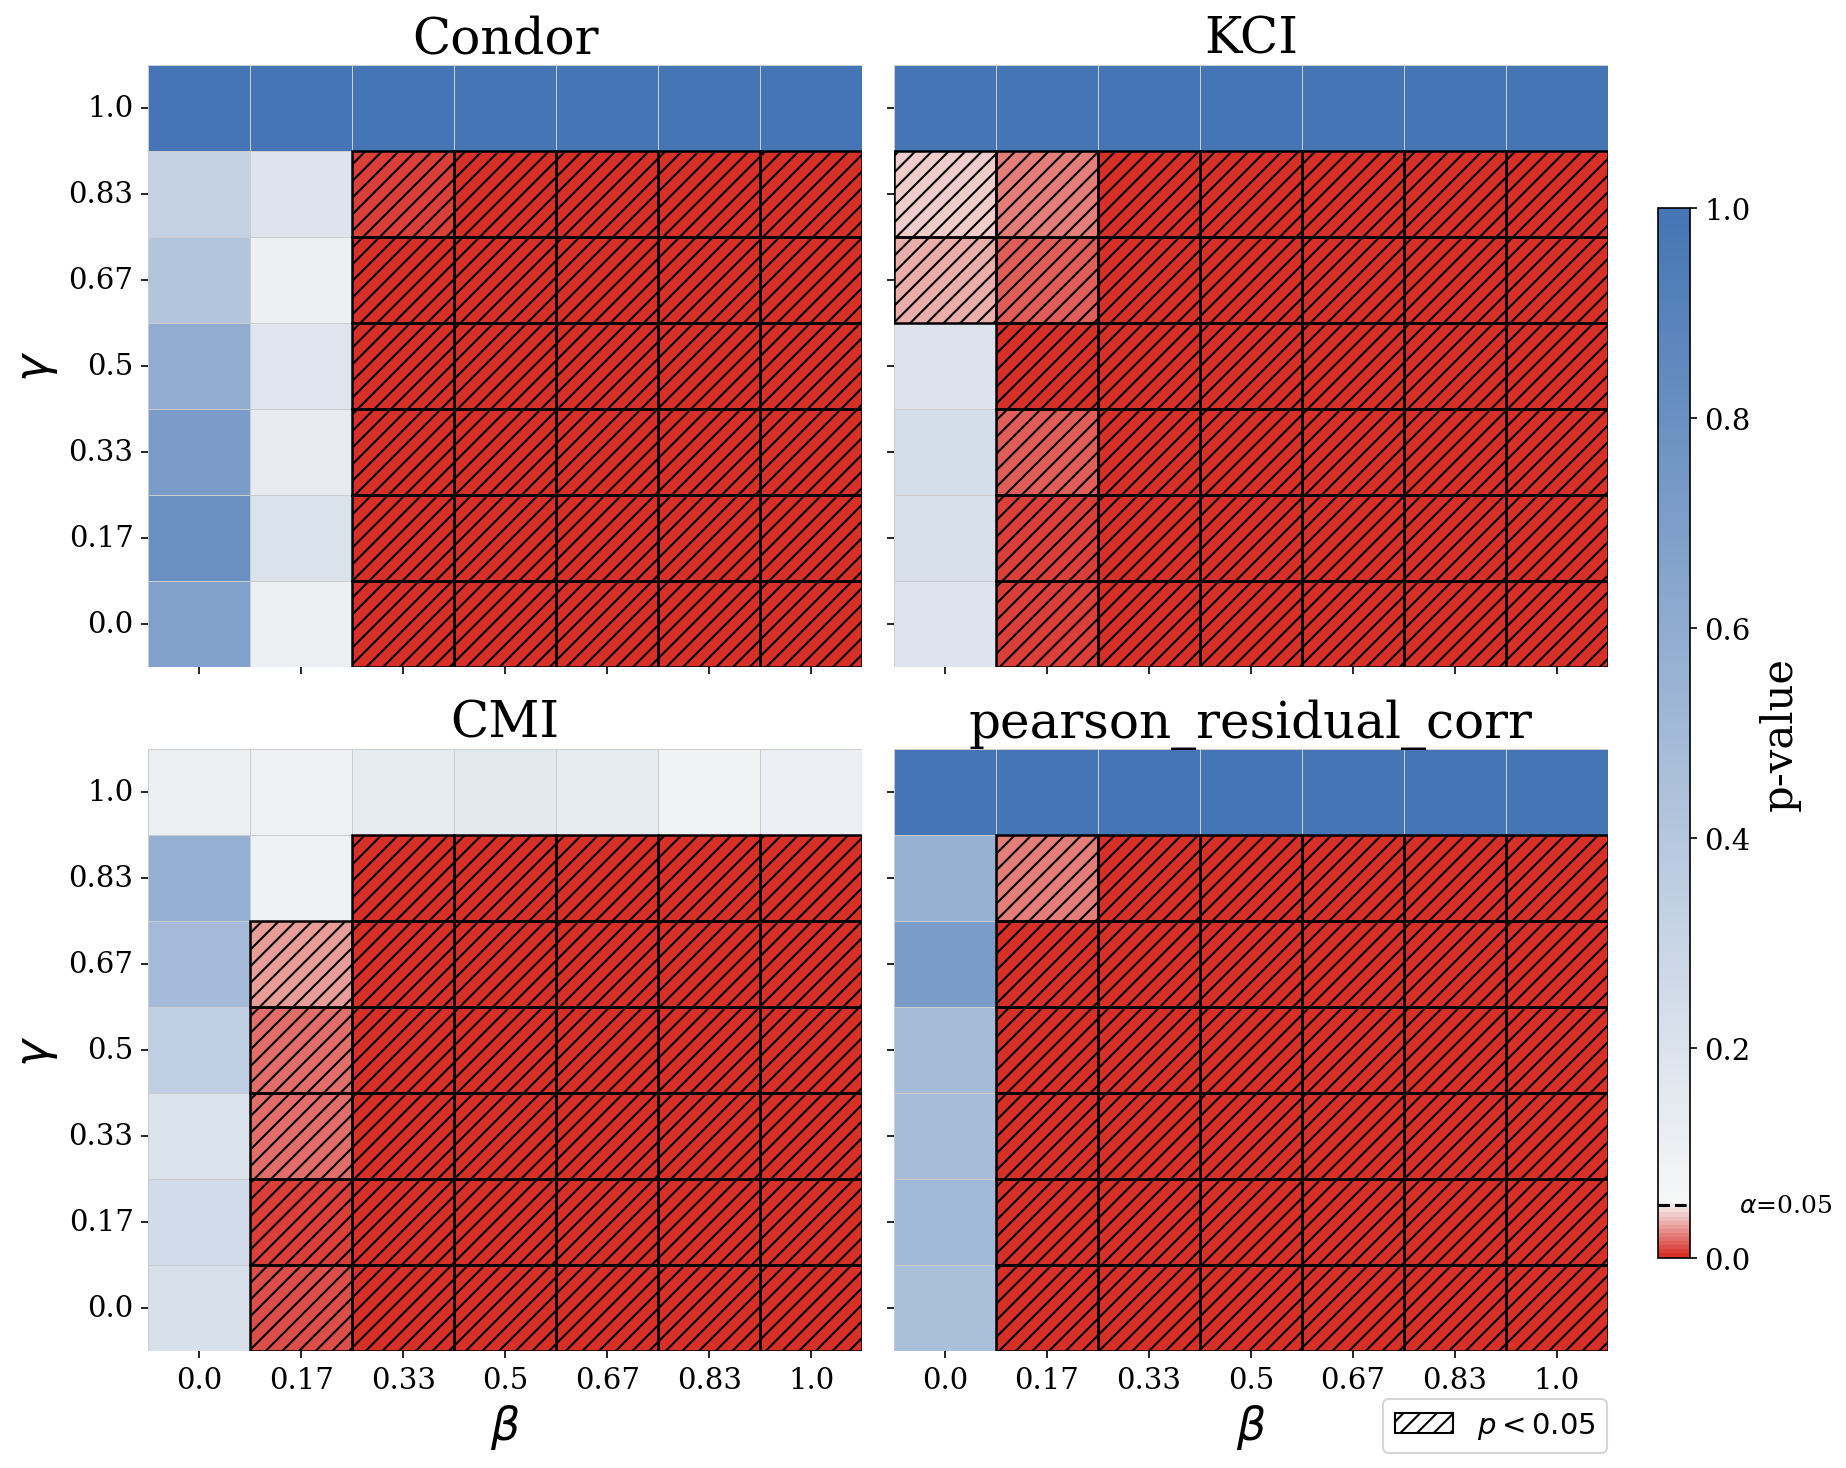

In [4]:
# ── Figure 1: Synthetic heatmaps (p-values over γ × β) ───────────

n_methods = len(syn_method_order)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True, sharex=True)

for i, method_key in enumerate(syn_method_order):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    df = pd.DataFrame(
        results_synthetic[method_key],
        index=np.round(gamma_values, 2),
        columns=np.round(beta_values, 2),
    )
    
    # Main heatmap
    sns.heatmap(
        df, cmap=CMAP, fmt=".3f", ax=ax,
        vmin=0, vmax=1, cbar=False,
        linewidths=0.4, linecolor='#cccccc',
    )
    ax.invert_yaxis()
    
    # Hatching for cells with p < α
    for row_idx in range(df.shape[0]):
        for col_idx in range(df.shape[1]):
            if df.iloc[row_idx, col_idx] < ALPHA:
                ax.add_patch(plt.Rectangle(
                    (col_idx, row_idx), 1, 1,
                    fill=False, edgecolor='black', linewidth=1.2,
                    hatch='///', zorder=5,
                ))
    
    ax.set_title(METHOD_DISPLAY.get(method_key, method_key), fontsize=24)
    
    if col == 0:
        ax.set_ylabel(r'$\gamma$', fontsize=22)
    if row == 1:
        ax.set_xlabel(r'$\beta$', fontsize=22)
    ax.tick_params(axis='y', rotation=0)
    ax.label_outer()

# Single colorbar
cbar_ax = fig.add_axes([0.93, 0.15, 0.018, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('p-value', fontsize=20)
cbar.ax.tick_params(labelsize=14)
# Mark α threshold on colorbar
cbar.ax.axhline(y=ALPHA, color='black', linewidth=1.5, linestyle='--')
cbar.ax.text(2.5, ALPHA, rf'$\alpha$={ALPHA}', fontsize=12, va='center')

# Hatching legend
hatch_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label=rf'$p < {ALPHA}$')
fig.legend(handles=[hatch_patch], loc='lower right', bbox_to_anchor=(0.91, 0.01), fontsize=14, frameon=True)

plt.tight_layout(rect=[0, 0, 0.92, 1.0])
plt.show()
fig.savefig(DATA_DIR / f"heatmap_synthetic_n_{n}_d_o_{d_o}_d_p_{d_p}_K_{K}_B_{B}_improved.pdf")

/tmp/ipykernel_644766/1904252387.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1.0])


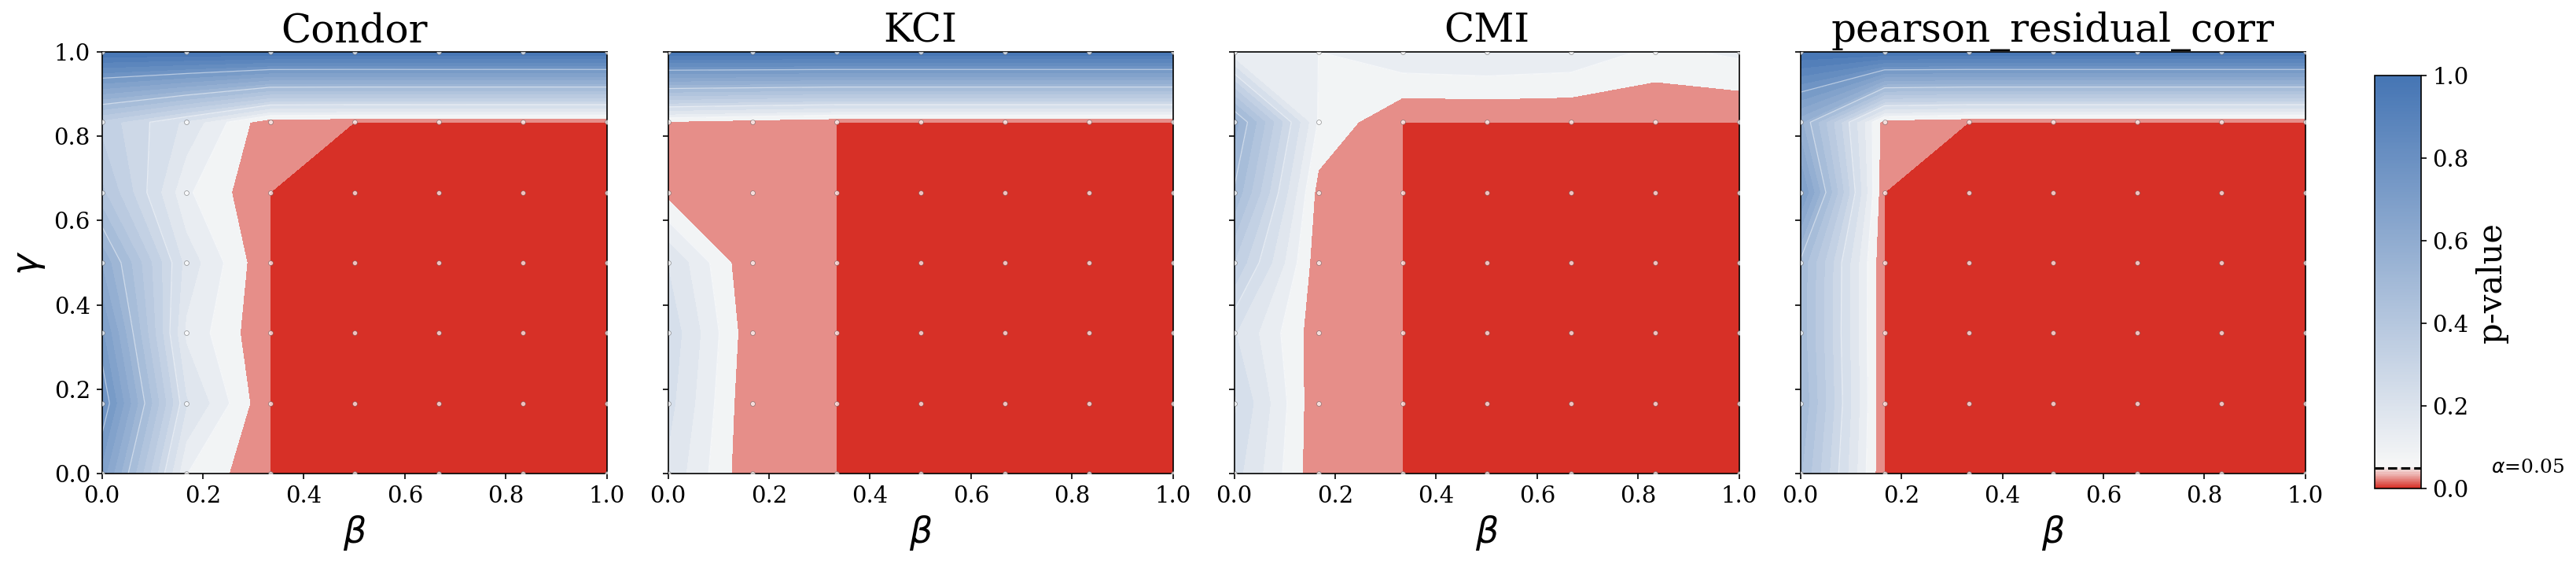

In [5]:
# ── Figure 1b: Synthetic contour plots (p-values over γ × β) ─────
from scipy.ndimage import gaussian_filter

n_methods = len(syn_method_order)
fig, axes = plt.subplots(1, n_methods, figsize=(5.5 * n_methods, 5), sharey=True, sharex=True)

# Contour levels
levels = np.linspace(0, 1, 21)

for i, method_key in enumerate(syn_method_order):
    ax = axes[i]
    Z = results_synthetic[method_key].astype(float)
    
    # Light Gaussian smoothing for nicer contours (sigma=0.6 keeps it close to data)
    Z_smooth = gaussian_filter(Z, sigma=0.01)
    
    # Filled contour
    cf = ax.contourf(
        beta_values, gamma_values, Z_smooth,
        levels=levels, cmap=CMAP, vmin=0, vmax=1, extend='both',
    )
    
    # Contour lines for key levels
    #cs = ax.contour(
    #    beta_values, gamma_values, Z_smooth,
    #    levels=[ALPHA], colors='black', linewidths=2.5, linestyles='--',
    #)
    #ax.clabel(cs, fmt=r'$\alpha$=%.2f' % ALPHA, fontsize=11, inline=True,inline_spacing=8)
    
    # Light contour lines for other levels
    cs2 = ax.contour(
        beta_values, gamma_values, Z_smooth,
        levels=[0.1, 0.25, 0.5, 0.75], colors='white', linewidths=0.6, alpha=0.5,
    )
    
    # Original data points as small dots
    B_grid, G_grid = np.meshgrid(beta_values, gamma_values)
    ax.scatter(B_grid.ravel(), G_grid.ravel(), c='white', s=8, edgecolors='#555555',
               linewidths=0.3, zorder=5, alpha=0.7)
    
    ax.set_title(METHOD_DISPLAY.get(method_key, method_key), fontsize=24)
    if i == 0:
        ax.set_ylabel(r'$\gamma$', fontsize=22)
    ax.set_xlabel(r'$\beta$', fontsize=22)
    ax.tick_params(labelsize=14)
    ax.set_xlim(beta_values[0], beta_values[-1])
    ax.set_ylim(gamma_values[0], gamma_values[-1])

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('p-value', fontsize=20)
cbar.ax.tick_params(labelsize=14)
cbar.ax.axhline(y=ALPHA, color='black', linewidth=1.5, linestyle='--')
cbar.ax.text(2.5, ALPHA, rf'$\alpha$={ALPHA}', fontsize=12, va='center')

plt.tight_layout(rect=[0, 0, 0.91, 1.0])
plt.show()
fig.savefig(DATA_DIR / f"contour_synthetic_n_{n}_d_o_{d_o}_d_p_{d_p}_K_{K}_B_{B}.pdf")

### 2. Semi-Synthetic Results (Adult & Compas)

In [6]:
# ── Section 2 config ──────────────────────────────────────────────
semi_method_order = ['Condor', 'nKCI', 'partial_dcorr_score', 'cmi_score', 'nhsic']

datasets_d = {
    "propublica": [['African_American'], ['Female'], ['random']],
    "adults":     [['gender'], ['race'], ['random']],
}
d_name = {"propublica": "Compas", "adults": "Adult"}

/tmp/ipykernel_644766/3160525409.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1.0])


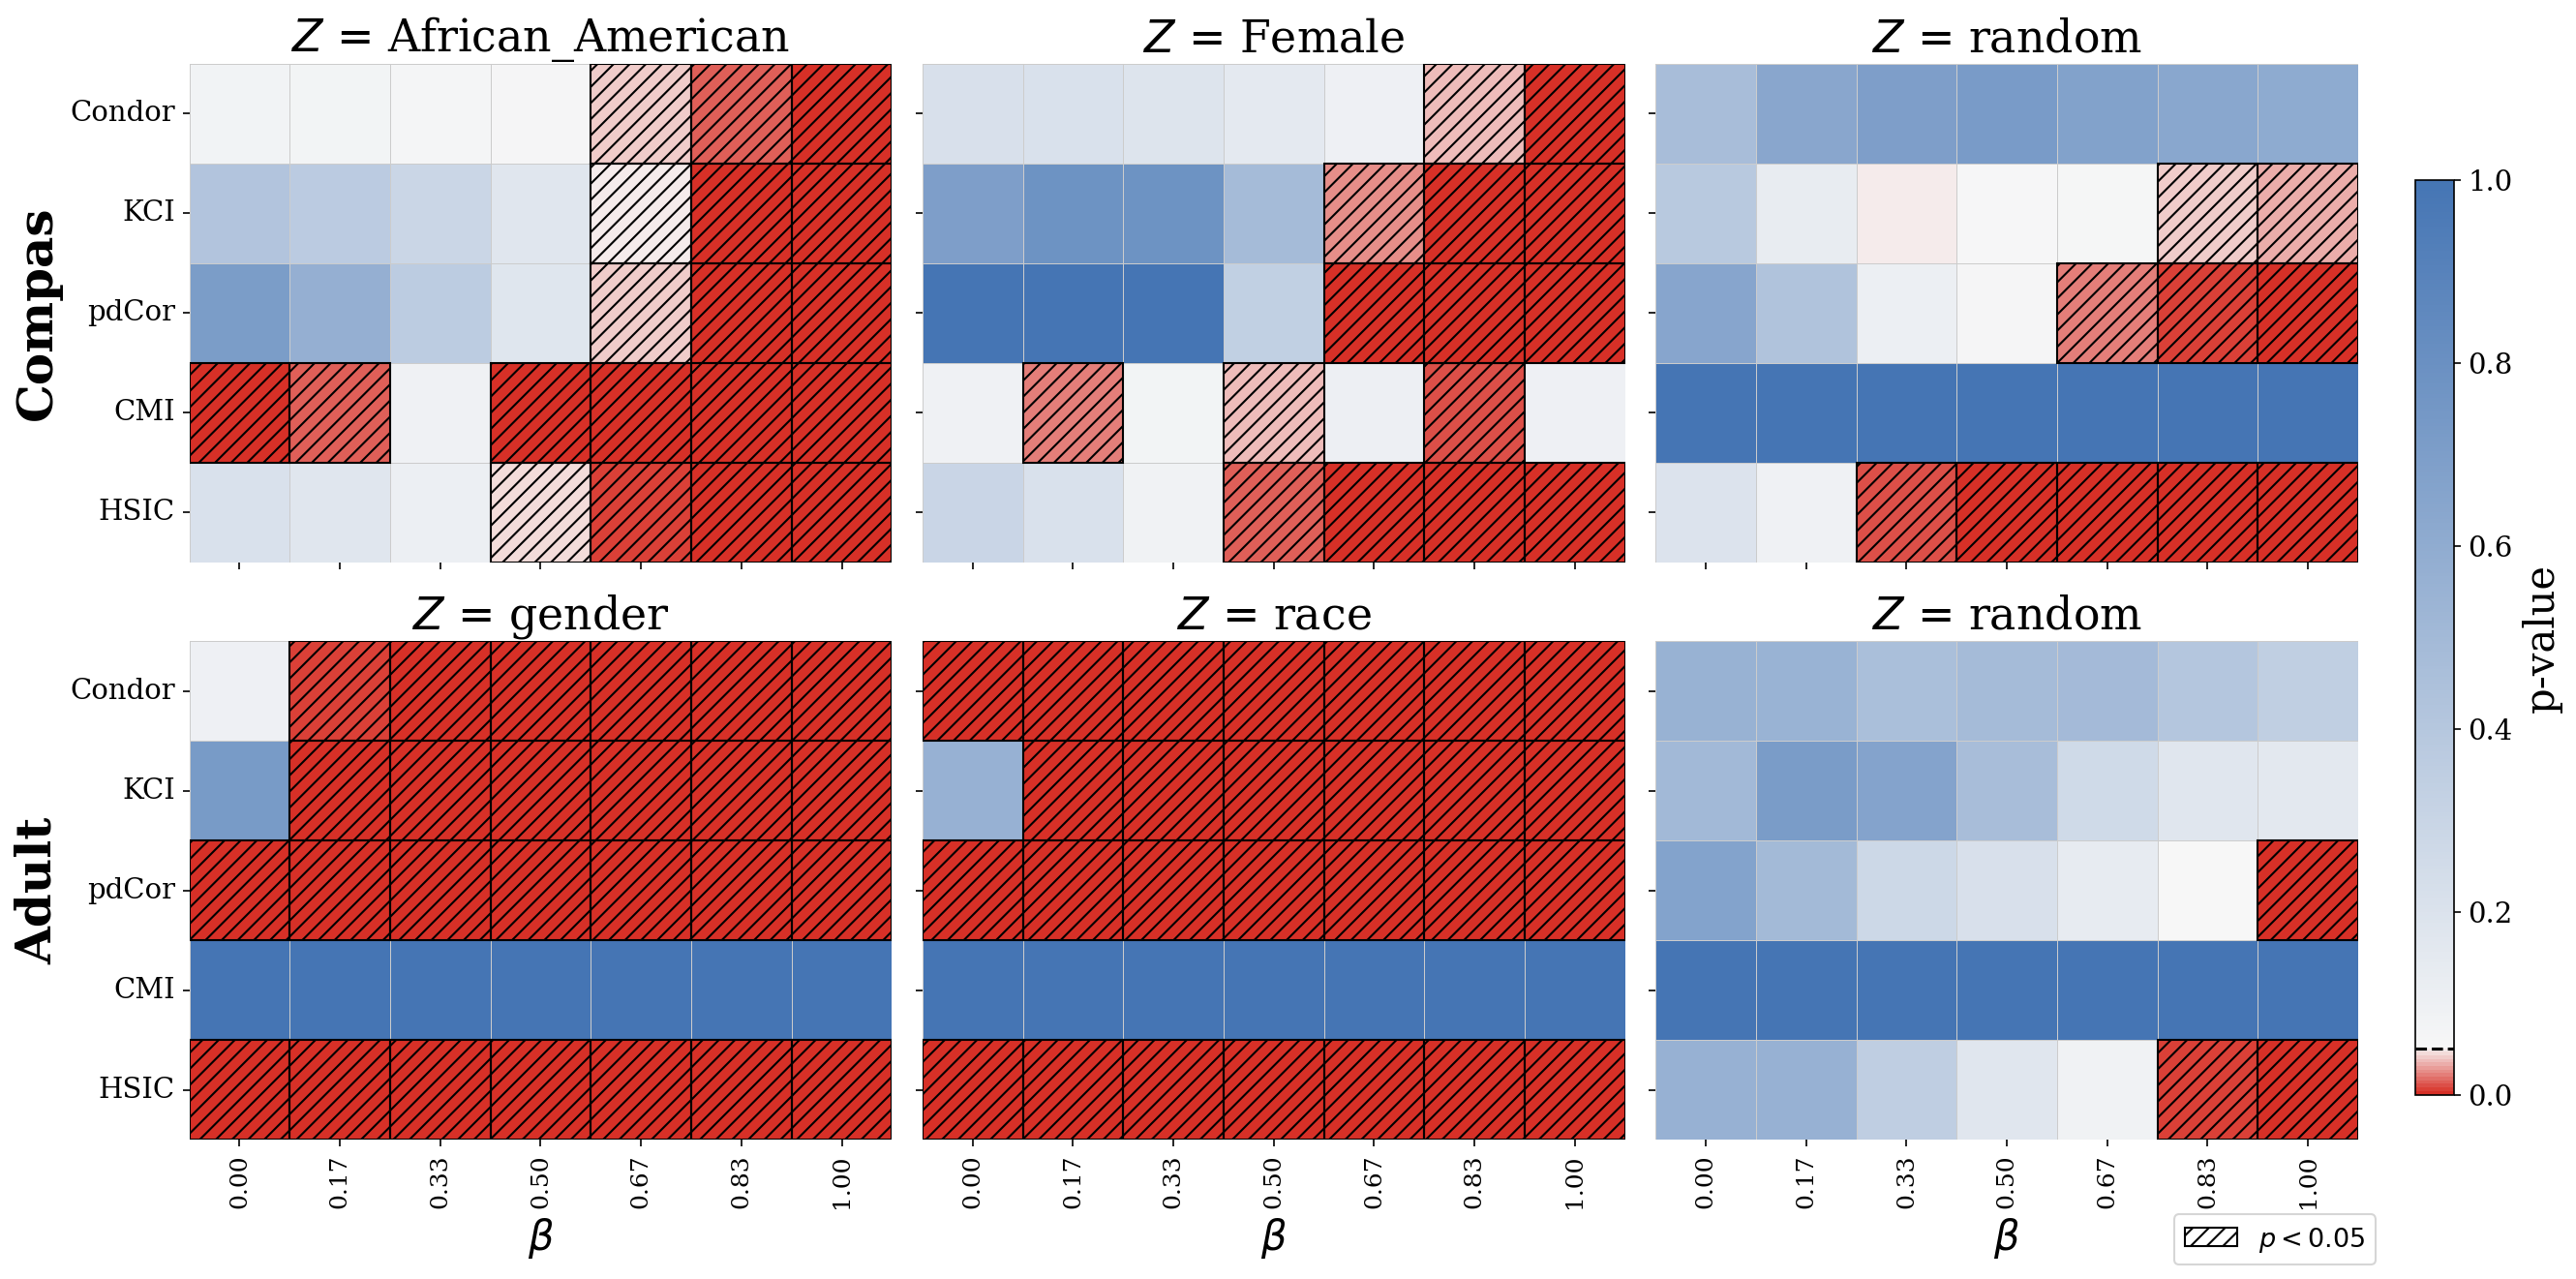

In [7]:
# ── Figure 2: Semi-synthetic heatmaps (methods × β per dataset/feature) ──

n_rows = len(datasets_d)
n_cols = len(next(iter(datasets_d.values())))  # features per dataset
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharey=True)

for dataset_idx, (dataset_key, dataset_features) in enumerate(datasets_d.items()):
    for col_idx, f_p in enumerate(dataset_features):
        ax = axes[dataset_idx, col_idx]

        # Load data
        fname = DATA_DIR / f"exp_betas_dataset_name_{dataset_key}_f_p_{f_p[0]}_B_{B}_K_{K}_betas_{linspace_dim}_size_{s_size}_iii.pkl"
        with open(fname, 'rb') as f:
            results_betas = pickle.load(f)
        #print(results_betas)
        # Reorder and rename methods
        results_ordered = results_betas.T.reindex(semi_method_order).rename(
            index=METHOD_DISPLAY
        )

        # Plot heatmap
        sns.heatmap(
            results_ordered, cmap=CMAP, fmt=".3f",
            linewidths=0.4, linecolor='#cccccc',
            vmin=0, vmax=1, cbar=False, ax=ax,
        )

        # Hatching for p < α
        for r in range(results_ordered.shape[0]):
            for c in range(results_ordered.shape[1]):
                if results_ordered.iloc[r, c] < ALPHA:
                    ax.add_patch(plt.Rectangle(
                        (c, r), 1, 1, fill=False,
                        edgecolor='black', linewidth=1.0, hatch='///', zorder=5,
                    ))

        # Labels
        if col_idx == 0:
            ax.set_ylabel(d_name[dataset_key], fontsize=24, fontweight='bold')
        else:
            ax.set_ylabel('')

        # Always format x-tick labels nicely
        ax.set_xticklabels([f"{b:.2f}" for b in beta_values], fontsize=12)
        
        if dataset_idx == n_rows - 1:
            ax.set_xlabel(r'$\beta$', fontsize=20)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)

        ax.set_title(rf'$Z$ = {f_p[0]}', fontsize=22)
        ax.tick_params(axis='y', rotation=0, labelsize=14)

# Colorbar
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('p-value', fontsize=20)
cbar.ax.tick_params(labelsize=14)
cbar.ax.axhline(y=ALPHA, color='black', linewidth=1.5, linestyle='--')

# Hatching legend
hatch_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label=rf'$p < {ALPHA}$')
fig.legend(handles=[hatch_patch], loc='lower right', bbox_to_anchor=(0.92, 0.01), fontsize=13, frameon=True)

plt.tight_layout(rect=[0, 0, 0.92, 1.0])
plt.show()
fig.savefig(DATA_DIR / f"heatmap_semisynthetic_B_{B}_K_{K}_improved.pdf")

### 3. Semi-Synthetic Causal Interpretation — Polar Plots (2×2)

Four polar plots: Compas (African American, Female) and Adult (race, gender).
Each quadrant encodes the causal interpretation of the joint (CRT, HSIC) decision.

In [8]:
# ── Polar plot configuration ──────────────────────────────────────
# 4 cases: 2 datasets × 2 protected features (excluding 'random')
polar_cases = [
    ("propublica", "African_American", "Compas ($Z$ = African American)"),
    ("propublica", "Female",           "Compas ($Z$ = Female)"),
    ("adults",     "race",             "Adult ($Z$ = Race)"),
    ("adults",     "gender",           "Adult ($Z$ = Gender)"),
]

# Methods to show in polar plots (excluding nhsic since it's used as the second test)
polar_methods = ['Condor', 'nKCI', 'cmi_score', 'partial_dcorr_score']

# Quadrant semantics (matching Causal Interpretation diagram):
#   Vertical axis:   Conditional Test   (Z ⊥⊥ R | X)  →  CRT:  Yes=top, No=bottom
#   Horizontal axis: Unconditional Test  (Z ⊥⊥ R)      →  HSIC: Yes=left, No=right
QUADRANT_COLORS = {
    'fair':       '#4575b4',   # blue   — top-left   (CRT ≥ α, HSIC ≥ α)
    'indirect':   '#fdae61',   # amber  — top-right  (CRT ≥ α, HSIC < α)  Z→X→R
    'impossible': '#999999',   # gray   — bottom-left (CRT < α, HSIC ≥ α)
    'direct':     '#d73027',   # red    — bottom-right(CRT < α, HSIC < α)  Z→R
}

QUADRANT_LABELS = {
    'fair':       r'$Z$ unrelated to' + '\n' + r'$X \rightarrow R$',
    'indirect':   'Indirect\nInfluence',
    'impossible': 'Causally\nImpossible',
    'direct':     'Direct\nInfluence',
}

# Marker per method — distinct shapes for clarity
MARKERS = {
    'Condor':               'o',   # circle
    'nKCI':                 's',   # square
    'cmi_score':            '^',   # triangle
    'partial_dcorr_score':  '*',   # star
}

print(f"Polar plot configured for {len(polar_cases)} cases ✓")

Polar plot configured for 4 cases ✓


In [9]:
# ── Helper: classify each (method, beta) point into a quadrant ────
def classify_quadrant(p_crt, p_hsic, alpha=0.05):
    """Return quadrant key based on CRT (conditional) and HSIC (unconditional).
    
    Cond / Uncond  |  Yes (HSIC>=a)   |  No (HSIC<a)
    ---------------|------------------|------------------
    Yes (CRT>=a)   |  fair (TL)       |  indirect (TR)
    No  (CRT<a)    |  impossible (BL) |  direct (BR)
    """
    if p_crt >= alpha and p_hsic >= alpha:
        return 'fair'
    elif p_crt >= alpha and p_hsic < alpha:
        return 'indirect'
    elif p_crt < alpha and p_hsic >= alpha:
        return 'impossible'
    else:
        return 'direct'

# ── Build polar data for all 4 cases ────────────────────────────
all_polar_data = {}
for ds_key, feat, title in polar_cases:
    fname = DATA_DIR / f"exp_betas_dataset_name_{ds_key}_f_p_{feat}_B_{B}_K_{K}_betas_{linspace_dim}_size_{s_size}_iii.pkl"
    with open(fname, 'rb') as f:
        df_betas = pickle.load(f)
    
    rows = []
    for method in polar_methods:
        if method not in df_betas.columns:
            continue
        for beta_val, p_crt in zip(df_betas.index, df_betas[method]):
            p_hsic = df_betas.loc[beta_val, 'nhsic'] if 'nhsic' in df_betas.columns else np.nan
            q = classify_quadrant(p_crt, p_hsic)
            rows.append({
                'method': method,
                'beta': beta_val,
                'p_crt': p_crt,
                'p_hsic': p_hsic,
                'quadrant': q,
            })
    all_polar_data[(ds_key, feat)] = pd.DataFrame(rows)

print(f"Polar data prepared for {len(all_polar_data)} cases ✓")

Polar data prepared for 4 cases ✓


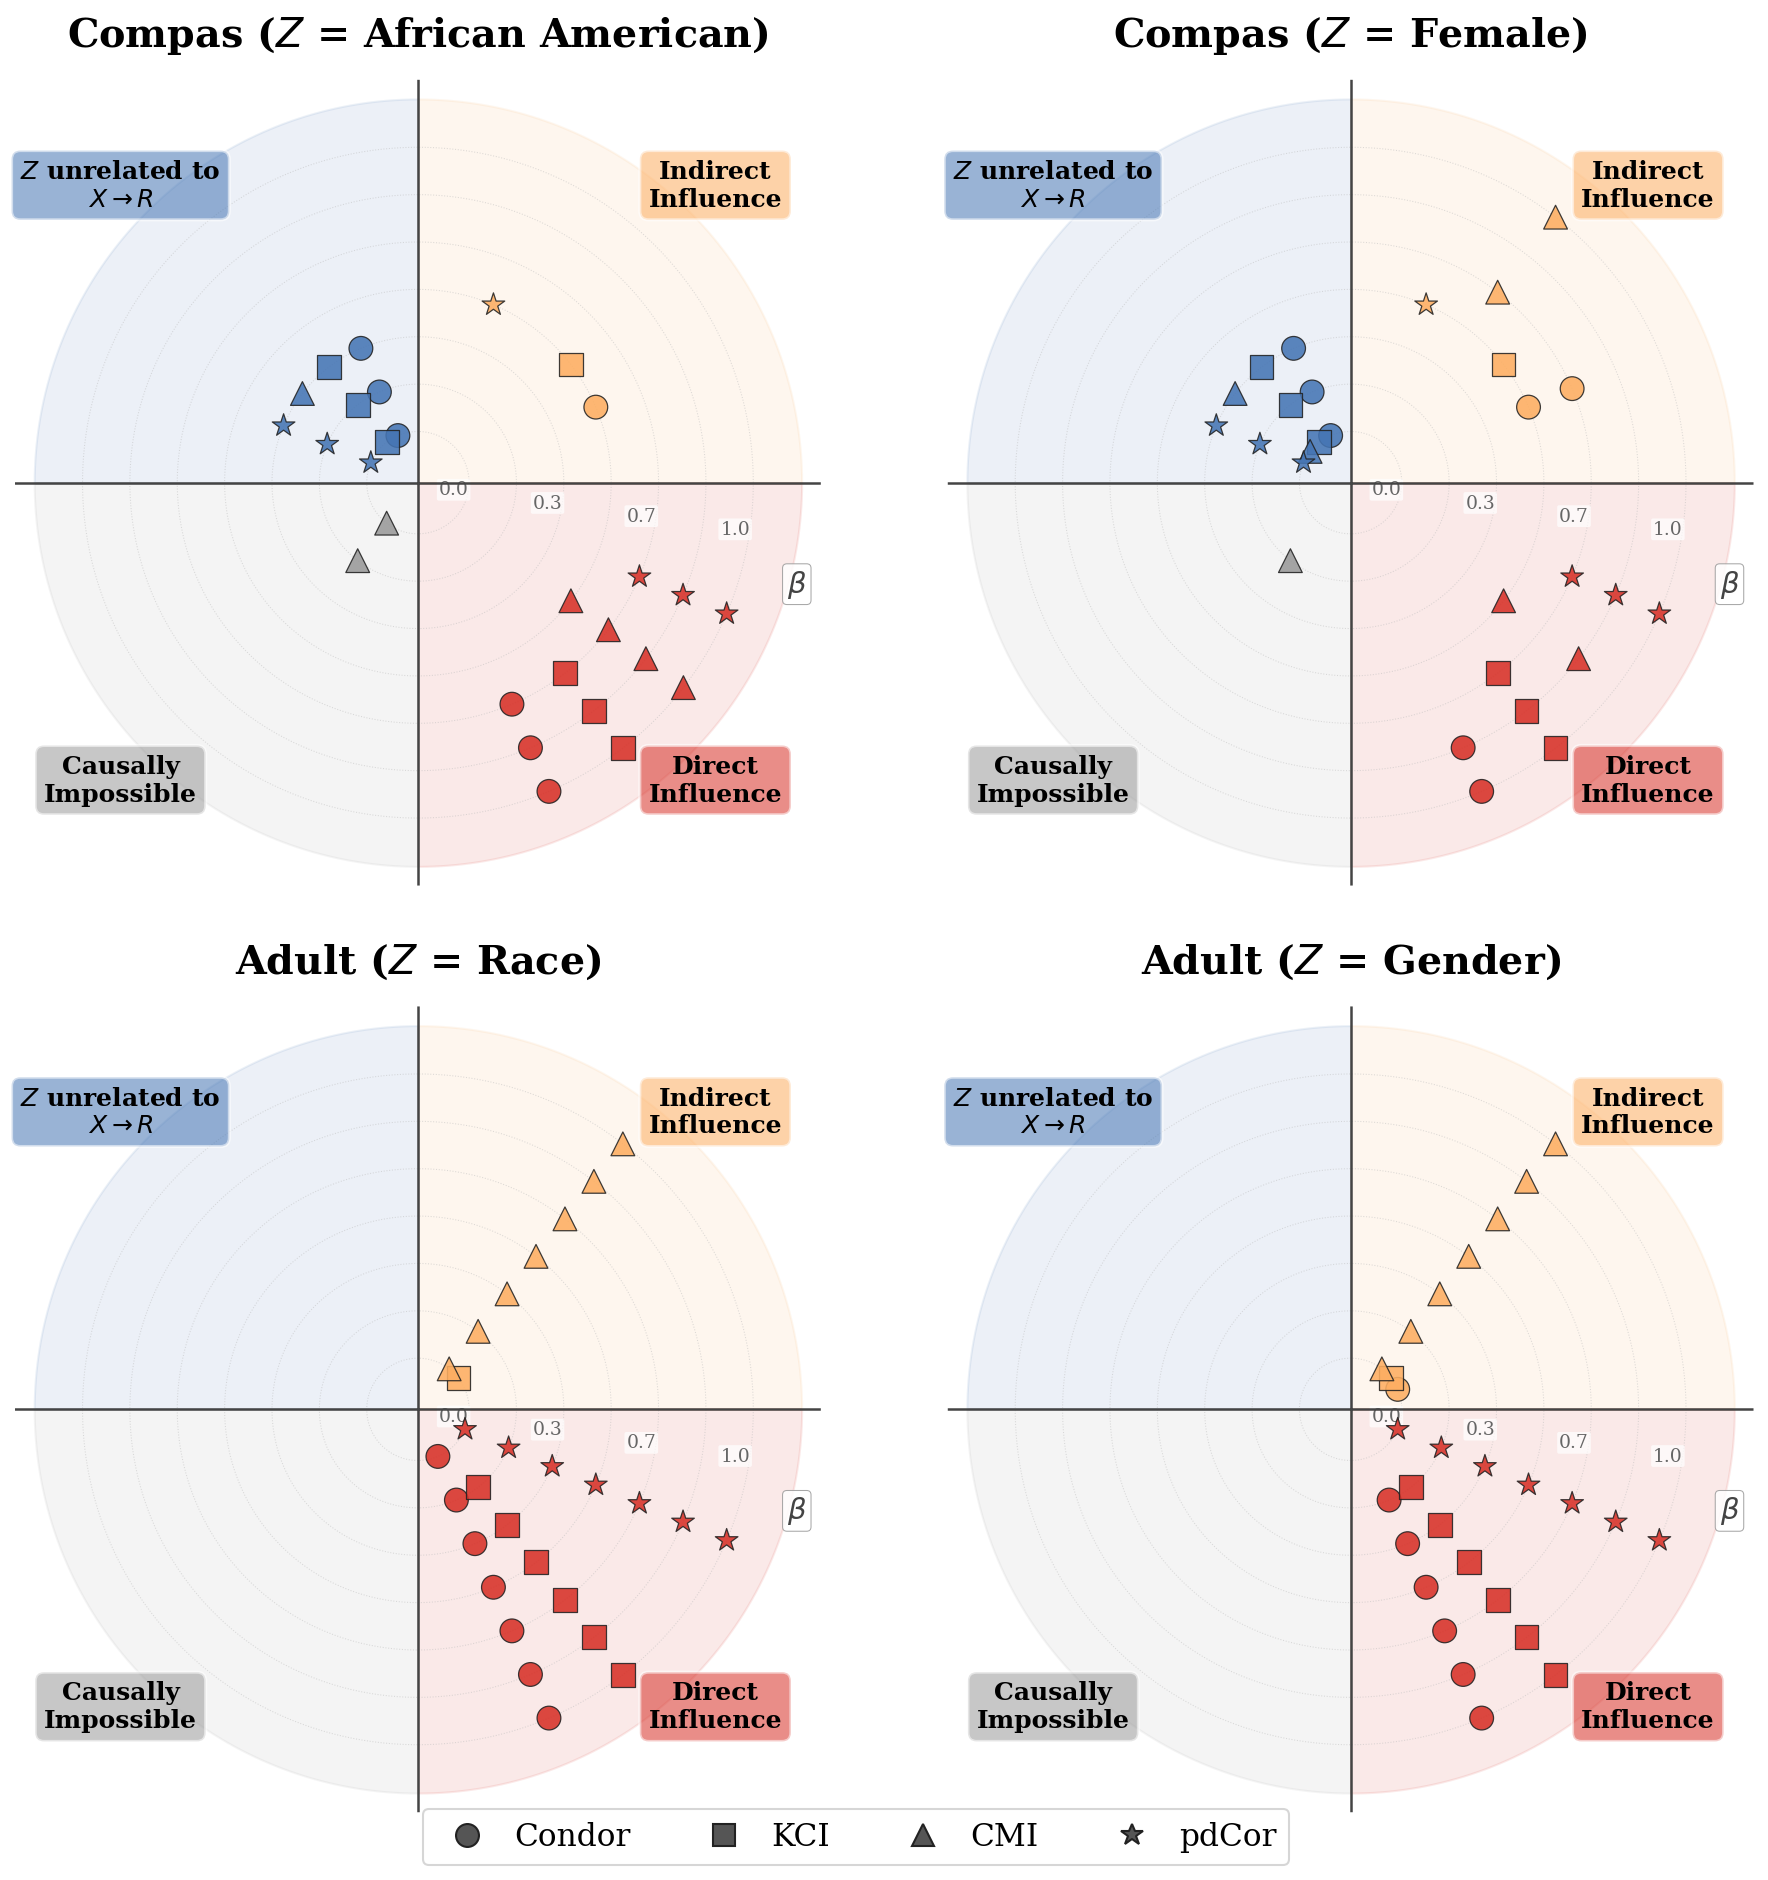

In [10]:
# ── Figure 3: 2×2 Polar Plots — Causal Interpretation ────────────
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

# Quadrant → base angle (centre of the 90° sector)
QUADRANT_BASE = {
    'fair':       np.pi * 3/4,   # top-left      (90–180°)
    'indirect':   np.pi * 1/4,   # top-right     (0–90°)
    'impossible': np.pi * 5/4,   # bottom-left   (180–270°)
    'direct':     np.pi * 7/4,   # bottom-right  (270–360°)
}

# Light background tints for each quadrant sector (very transparent)
QUADRANT_BG = {
    'fair':       '#4575b4',
    'indirect':   '#fdae61',
    'impossible': '#999999',
    'direct':     '#d73027',
}

# Only label a subset of β values to reduce clutter
beta_label_indices = [0, 2, 4, 6]  # 0.00, 0.33, 0.67, 1.00

fig, axes = plt.subplots(2, 2, figsize=(15, 15), subplot_kw=dict(projection='polar'))
fig.subplots_adjust(hspace=0.15, wspace=0.15)

for ax_idx, (ds_key, feat, title) in enumerate(polar_cases):
    row, col = divmod(ax_idx, 2)
    ax = axes[row, col]
    pdf = all_polar_data[(ds_key, feat)]

    # ── Light quadrant background fills ───────────────────────
    max_r = 1.35
    for qkey, base_a in QUADRANT_BASE.items():
        start_deg = np.rad2deg(base_a) - 45
        end_deg = np.rad2deg(base_a) + 45
        # Fill sector with many thin wedges
        theta_fill = np.linspace(np.deg2rad(start_deg), np.deg2rad(end_deg), 80)
        r_fill = np.full_like(theta_fill, max_r)
        ax.fill_between(theta_fill, 0, r_fill,
                        color=QUADRANT_BG[qkey], alpha=0.10, zorder=0)

    # ── Assign angular offsets per method within each quadrant ─
    n_methods = len(polar_methods)
    method_offsets = np.linspace(-np.deg2rad(22), np.deg2rad(22), n_methods)
    method_offset_map = dict(zip(polar_methods, method_offsets))

    for method in polar_methods:
        mdf = pdf[pdf['method'] == method]
        if mdf.empty:
            continue

        thetas, radii, colors = [], [], []
        for _, pt in mdf.iterrows():
            base_angle = QUADRANT_BASE[pt['quadrant']]
            theta = base_angle + method_offset_map[pt['method']]
            thetas.append(theta)
            radii.append(pt['beta'] + 0.18)
            colors.append(QUADRANT_COLORS[pt['quadrant']])

        ax.scatter(
            thetas, radii,
            c=colors, s=130,
            marker=MARKERS[method],
            label=METHOD_DISPLAY.get(method, method),
            alpha=0.88, edgecolors='#222222', linewidths=0.6,
            zorder=10,
        )

    # ── Styling ───────────────────────────────────────────────
    ax.set_xticklabels([])
    ax.grid(False)
    ax.set_rgrids([])
    ax.set_thetagrids([])

    # Concentric β circles (lighter, fewer labels)
    for idx_bv, bv in enumerate(beta_values):
        theta_ring = np.linspace(0, 2 * np.pi, 200)
        ax.plot(theta_ring, np.full_like(theta_ring, bv + 0.18),
                color='#bbbbbb', linewidth=0.5, linestyle=':', alpha=0.5)
        # Only label selected β values — positioned at ~350° to stay clear
        if idx_bv in beta_label_indices:
            ax.text(np.deg2rad(352), bv + 0.18, f'{bv:.1f}', fontsize=9,
                    ha='right', va='center', color='#666666',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                              alpha=0.7, edgecolor='none'))

    # Quadrant dividers
    for angle in [0, np.pi/2, np.pi, 3*np.pi/2]:
        ax.axvline(x=angle, color='#444444', linewidth=1.2, zorder=3)

    # Quadrant labels — larger, better positioned
    label_r = 1.48
    for qkey, base_a in QUADRANT_BASE.items():
        ax.text(base_a, label_r, QUADRANT_LABELS[qkey], fontsize=12,
                ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.35',
                          facecolor=QUADRANT_COLORS[qkey], alpha=0.55,
                          edgecolor='white', linewidth=1.5))

    # β label — single, near the β value labels
    ax.text(np.deg2rad(345), 1.38, r'$\beta$', fontsize=14, ha='center', va='center',
            fontweight='bold', color='#444444',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.85,
                      edgecolor='#999999', linewidth=0.5))

    # Remove outer circle
    ax.spines['polar'].set_visible(False)
    ax.set_title(title, fontsize=19, pad=16, fontweight='bold')

# ── Shared legend (methods) — centred in the figure ───────────────
legend_handles = [
    plt.Line2D([0], [0], marker=MARKERS[m], color='w',
               markerfacecolor='#555555', markeredgecolor='#222222',
               markersize=11, linestyle='None',
               label=METHOD_DISPLAY.get(m, m))
    for m in polar_methods
]
fig.legend(handles=legend_handles, loc='center', ncol=len(polar_methods),
           fontsize=15, frameon=True, fancybox=True, edgecolor='#cccccc',
           bbox_to_anchor=(0.5, 0.099), handletextpad=0.5, columnspacing=2.0)

plt.show()
fig.savefig(DATA_DIR / f"polar_2x2_causal_B_{B}_K_{K}_improved.pdf")

### 4. Real Dataset

In [67]:
# ── Section 4: Real-Data Results ──────────────────────────────────
import pickle

# Dataset configuration: display name → (pkl path, list of feature groups)
datasets_config = {
    "Adult": {
        #"pkl": "/home/carloabrate/iii/exp_real_dataset_name_adults_B_200_K_5_size_1000.pkl",
        "pkl": "/home/carloabrate/iii/exp_real_dataset_name_adults_B_200_K_5_size_1100_drop.pkl",
        "features_Z": [['gender'], ['race']]#,   ['gender', 'race']]
    },
    "Compas": {
        "pkl": "/home/carloabrate/iii/exp_real_dataset_name_propublica_B_200_K_5_size_20000.pkl",
        "features_Z": [['African_American'], ['Female']]#, ['African_American', 'Female']]
    },
    "Law School": {
        "pkl": "/home/carloabrate/iii/exp_real_dataset_name_law_B_200_K_5_size_20000.pkl",
        #"pkl": "/home/carloabrate/iii/exp_real_dataset_name_law_B_200_K_5_size_1000_drop.pkl",
        "features_Z": [['sex'], ['race_nonwhite']],  # ['sex', 'race_nonwhite']
    },
    "Student Perf.": {
        "pkl": "/home/carloabrate/iii/exp_real_dataset_name_edu_B_200_K_5_size_20000.pkl",
        "features_Z": [['sex'], ['address']],  # ['sex', 'address']
    },
    "Stress Level": {
        "pkl": "/home/carloabrate/iii/exp_real_dataset_name_phone_B_200_K_5_size_1000.pkl",
        "features_Z": [['Age'], ['Gender']],  # ['Age', 'Gender']
    },
    #"Heart": {
    #    "pkl": "/home/carloabrate/iii/exp_real_dataset_name_heart_B_200_K_5_size_1000.pkl",
    #    "features_Z": [['Age'], ['Gender']],  # ['Age', 'Gender']
    #},
    #"Hiring": {
        #"pkl": "/home/carloabrate/iii/exp_real_dataset_name_hiring_B_200_K_5_size_1000.pkl",
        #"features_Z": [['Gender'], ['University']],  # ['Gender', 'University']
    #},
}

# Load all results
all_real_results = {}
for ds_name, cfg in datasets_config.items():
    try:
        with open(cfg["pkl"], "rb") as f:
            all_real_results[ds_name] = pickle.load(f)
        print(f"✓ Loaded {ds_name}")
    except FileNotFoundError:
        print(f"✗ Not found: {cfg['pkl']}")

print(f"\nDatasets loaded: {list(all_real_results.keys())}")

✓ Loaded Adult
✓ Loaded Compas
✓ Loaded Law School
✓ Loaded Student Perf.
✓ Loaded Stress Level

Datasets loaded: ['Adult', 'Compas', 'Law School', 'Student Perf.', 'Stress Level']


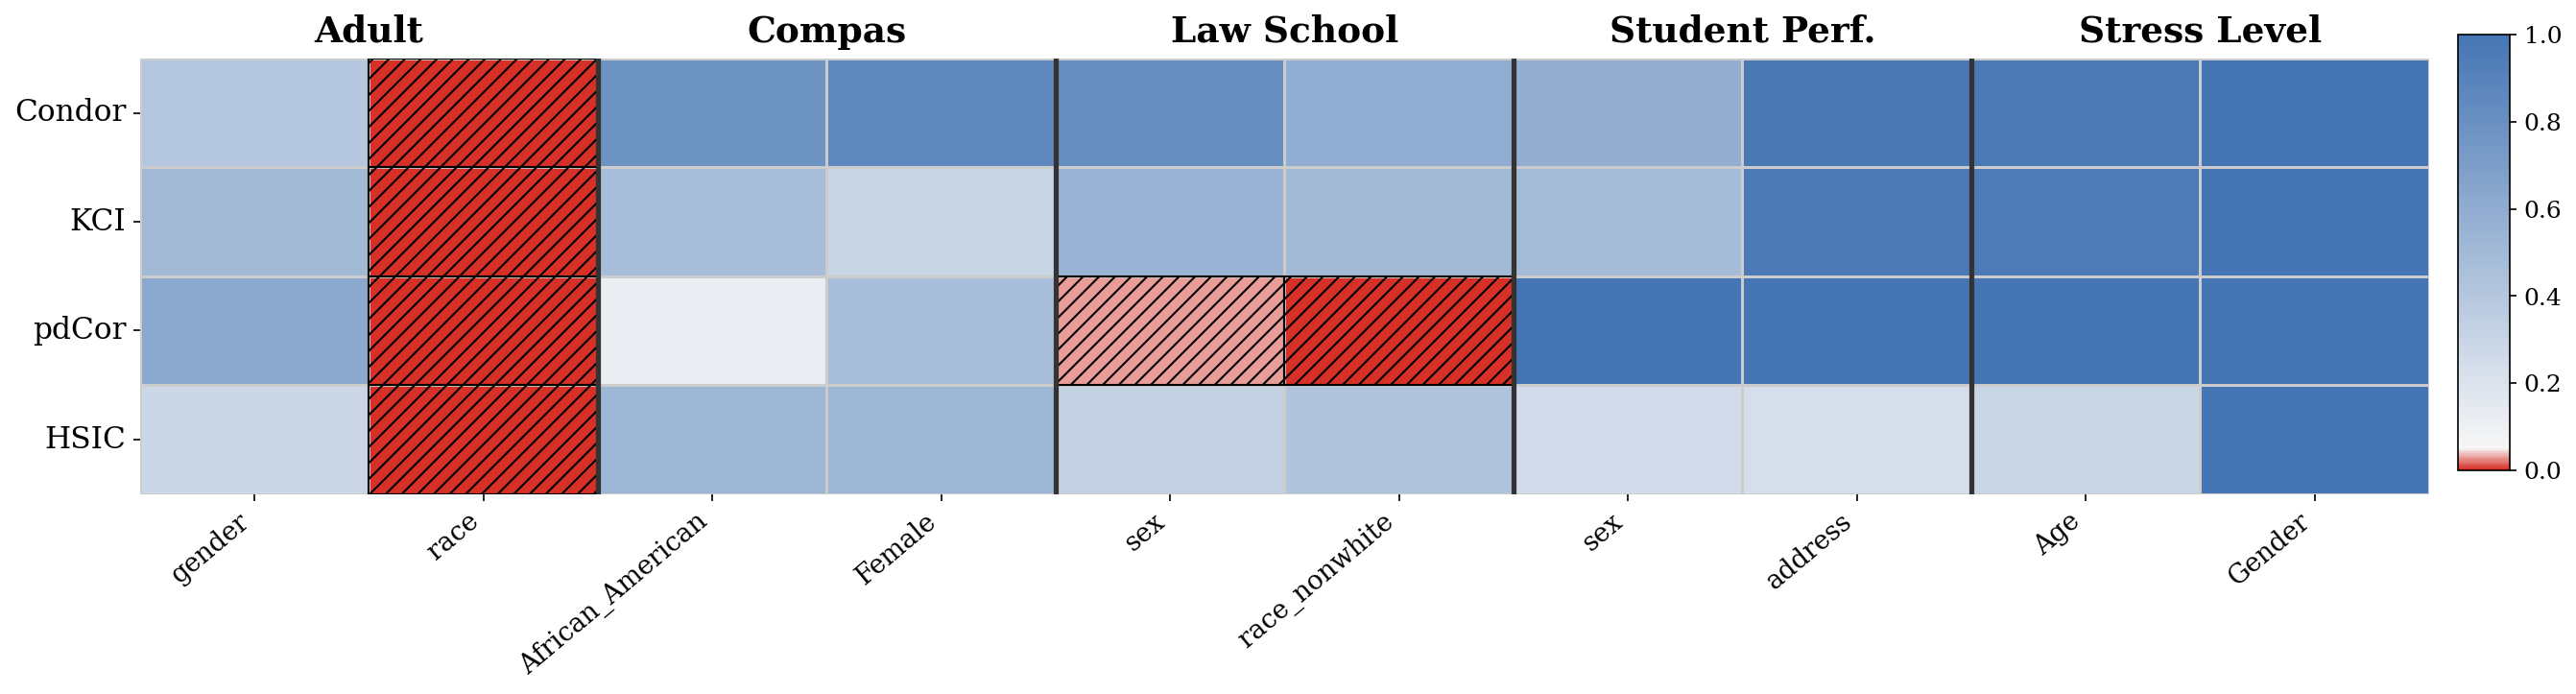

In [68]:

# ── Figure 4: Real-Data Heatmap (single table) ───────────────────

real_method_order = ['Condor', 'nKCI', 'partial_dcorr_score', 'nhsic']
real_method_display = {
    'Condor': 'Condor', 'nKCI': 'KCI',
    'nhsic': 'HSIC', 'partial_dcorr_score': 'pdCor',
}

# Build one wide DataFrame: rows = methods, columns = (dataset, feature)
col_tuples = []
for ds_name, cfg in datasets_config.items():
    for f in cfg['features_Z']:
        col_tuples.append((ds_name, ', '.join(f)))

col_index = pd.MultiIndex.from_tuples(col_tuples, names=['Dataset', 'Feature'])
row_labels = [real_method_display.get(m, m) for m in real_method_order]

df_all = pd.DataFrame(index=row_labels, columns=col_index, dtype=float)

for ds_name, cfg in datasets_config.items():
    results = all_real_results[ds_name]
    for feat_idx, f in enumerate(cfg['features_Z']):
        feat_label = ', '.join(f)
        feat_data = results.get(feat_idx, {})
        for method in real_method_order:
            pvals = feat_data.get(method, [np.nan])
            df_all.loc[real_method_display.get(method, method), (ds_name, feat_label)] = pvals[0]

# ── Plot ──────────────────────────────────────────────────────────
n_cols_data = len(col_tuples)
fig, ax = plt.subplots(figsize=(1.8 * n_cols_data + 2, 5.5))

sns.heatmap(
    df_all.astype(float), cmap=CMAP, #annot=True, fmt=".3f",
    vmin=0, vmax=1, cbar=False, ax=ax,
    linewidths=0.6, linecolor='#cccccc',
    annot_kws={'fontsize': 13},
)

# Hatching for p < α
for r in range(df_all.shape[0]):
    for c in range(df_all.shape[1]):
        val = df_all.iloc[r, c]
        if not np.isnan(val) and val < ALPHA:
            ax.add_patch(plt.Rectangle(
                (c, r), 1, 1, fill=False,
                edgecolor='black', linewidth=1.0, hatch='///', zorder=5,
            ))

# ── X-axis: feature names (bottom) ──────────────────────────────
ax.set_xticklabels(
    [feat.replace(', ', ',\n') for _, feat in col_tuples],
    fontsize=13, rotation=40, ha='right',
)

# ── Dataset group labels ABOVE the heatmap + bold vertical separators ─
prev_ds = None
group_start = 0
for i, (ds, _) in enumerate(col_tuples + [("__end__", "")]):
    if ds != prev_ds:
        if prev_ds is not None:
            mid = (group_start + i) / 2
            # Label above the heatmap
            ax.text(mid, 1.02, prev_ds, ha='center', va='bottom',
                    fontsize=18, fontweight='bold',
                    transform=ax.get_xaxis_transform())
            # Bold vertical separator between dataset groups
            if i < len(col_tuples):
                ax.axvline(x=i, color='#333333', linewidth=2.5, zorder=6)
        group_start = i
        prev_ds = ds

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0, labelsize=15)

# Colorbar
cbar_ax = fig.add_axes([0.93, 0.38, 0.018, 0.55])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
#cbar.set_label('p-value', fontsize=16)
cbar.ax.tick_params(labelsize=12)
#cbar.ax.axhline(y=ALPHA, color='black', linewidth=1., linestyle='--')
#cbar.ax.text(2.5, ALPHA, rf'$\alpha$={ALPHA}', fontsize=10, va='center')

# Hatching legend
#hatch_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///',label=rf'$p < {ALPHA}$')
#fig.legend(handles=[hatch_patch], loc='lower right',
           #bbox_to_anchor=(0.92, 0.02), fontsize=12, frameon=True)

plt.subplots_adjust(bottom=0.35, right=0.92, top=0.90)
plt.show()
fig.savefig(DATA_DIR / "heatmap_real_data_all_datasets.pdf")


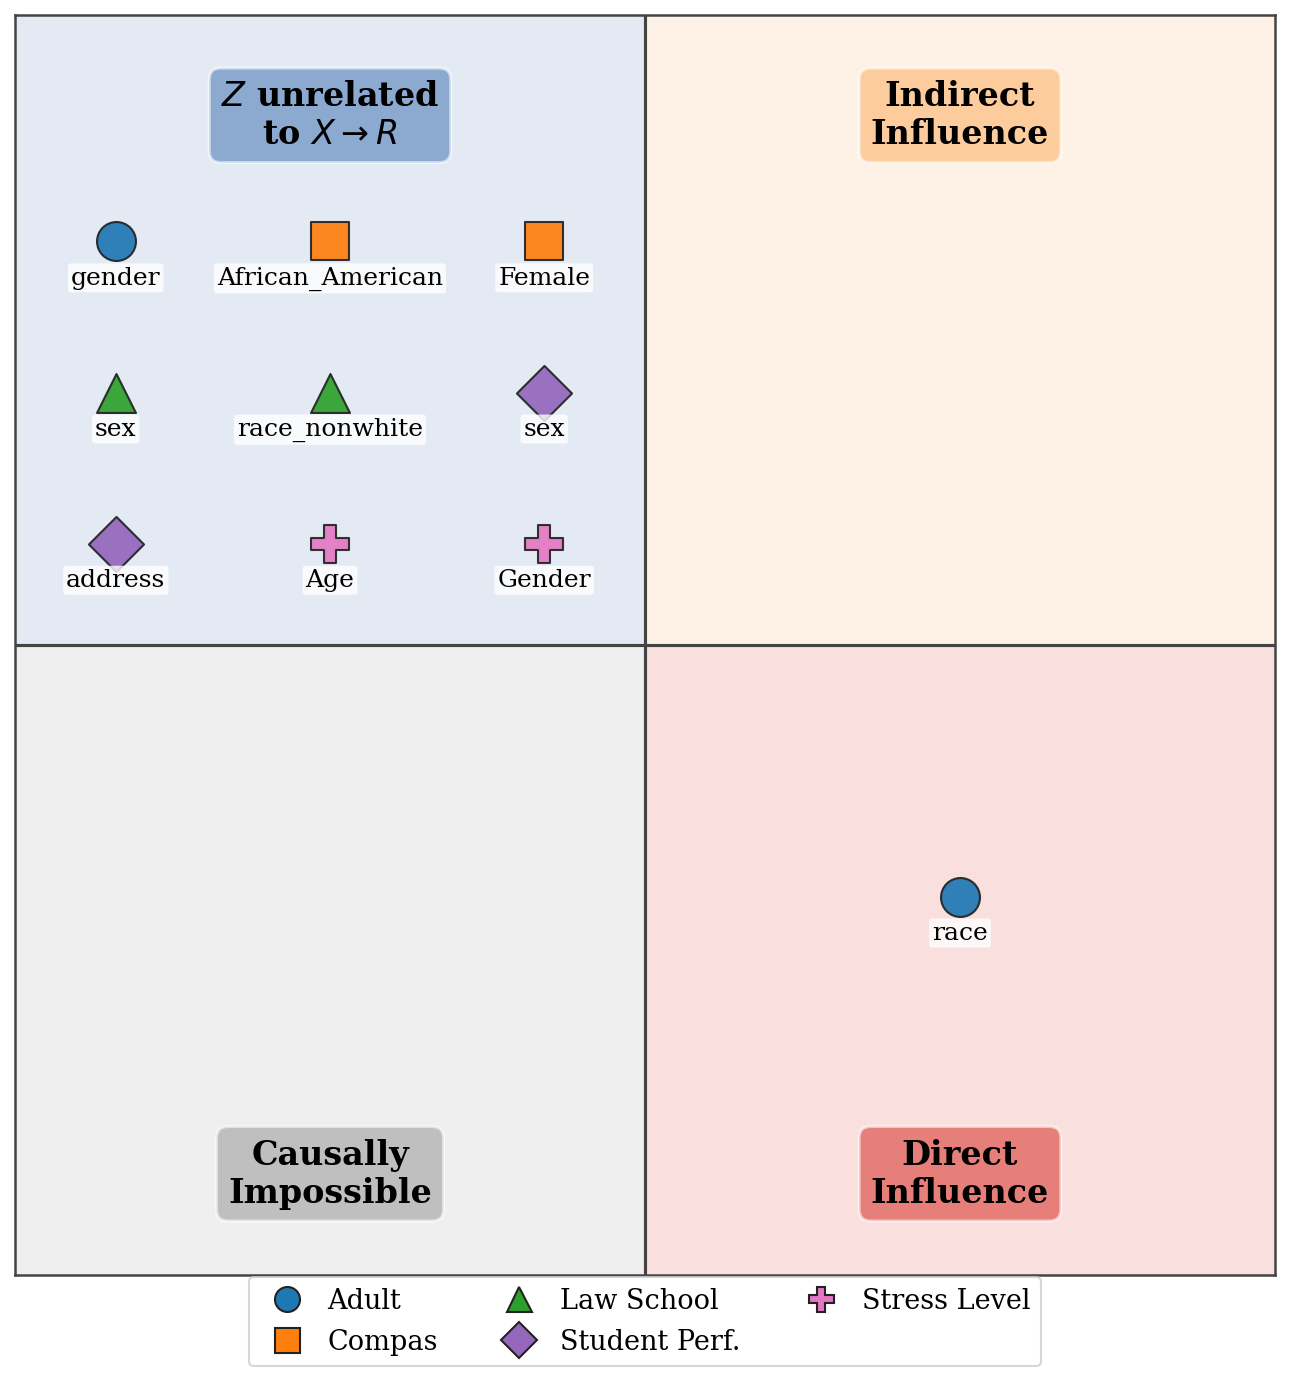

In [69]:

# ── Figure 4.1: Real-Data Causal Quadrant (Square Plot) ──────────
from collections import defaultdict

# ── Classification matching the Causal Interpretation diagram ─────
def classify_real(p_condor, p_hsic, alpha=0.05):
    if p_condor >= alpha and p_hsic >= alpha:
        return 'unrelated'
    elif p_condor >= alpha and p_hsic < alpha:
        return 'indirect'
    elif p_condor < alpha and p_hsic >= alpha:
        return 'impossible'
    else:
        return 'direct'

QUAD41_COLORS = {
    'unrelated':  '#4575b4',
    'impossible': '#999999',
    'indirect':   '#fdae61',
    'direct':     '#d73027',
}

QUAD41_LABELS = {
    'unrelated':  '$Z$ unrelated\nto $X \\rightarrow R$',
    'impossible': 'Causally\nImpossible',
    'indirect':   'Indirect\nInfluence',
    'direct':     'Direct\nInfluence',
}

# Quadrant → (x_min, x_max, y_min, y_max)
QUAD_BOUNDS = {
    'unrelated':  (0.0, 0.5, 0.5, 1.0),
    'indirect':   (0.5, 1.0, 0.5, 1.0),
    'impossible': (0.0, 0.5, 0.0, 0.5),
    'direct':     (0.5, 1.0, 0.0, 0.5),
}

DS_PALETTE = {
    'Adult':         '#1f77b4',
    'Compas':        '#ff7f0e',
    'Law School':    '#2ca02c',
    'Student Perf.': '#9467bd',
    'Stress Level':  '#e377c2',
}

DS_MARKERS = {
    'Adult':         'o',
    'Compas':        's',
    'Law School':    '^',
    'Student Perf.': 'D',
    'Stress Level':  'P',
}

# ── Collect points ───────────────────────────────────────────────
real_points = []
for ds_name, cfg in datasets_config.items():
    results = all_real_results.get(ds_name, {})
    for feat_idx, f_list in enumerate(cfg['features_Z']):
        feat_label = ', '.join(f_list)
        feat_data = results.get(feat_idx, {})
        p_condor = feat_data.get('Condor', [np.nan])[0]
        p_hsic   = feat_data.get('nhsic',  [np.nan])[0]
        if not np.isnan(p_condor) and not np.isnan(p_hsic):
            real_points.append({
                'dataset':  ds_name,
                'feature':  feat_label,
                'p_condor': p_condor,
                'p_hsic':   p_hsic,
                'quadrant': classify_real(p_condor, p_hsic),
            })

# Group by quadrant
quad_groups = defaultdict(list)
for pt in real_points:
    quad_groups[pt['quadrant']].append(pt)

# ── Build square figure ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

# Colored quadrant backgrounds
for qkey, (x0, x1, y0, y1) in QUAD_BOUNDS.items():
    ax.add_patch(plt.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        facecolor=QUAD41_COLORS[qkey], alpha=0.15,
        edgecolor='none', zorder=0,
    ))

# Divider lines
ax.axhline(y=0.5, color='#444444', linewidth=1.5, zorder=3)
ax.axvline(x=0.5, color='#444444', linewidth=1.5, zorder=3)

# ── Quadrant labels — centred in quadrant ─────────────────────────
label_centers = {
    'unrelated':  (0.25, 0.92),
    'indirect':   (0.75, 0.92),
    'impossible': (0.25, 0.08),
    'direct':     (0.75, 0.08),
}
for qkey, (lx, ly) in label_centers.items():
    ax.text(lx, ly, QUAD41_LABELS[qkey], fontsize=16,
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor=QUAD41_COLORS[qkey], alpha=0.55,
                      edgecolor='white', linewidth=1.5),
            zorder=12)

# ── Place points on grid inside each quadrant ────────────────────
grid_margin = 0.05
label_band  = 0.10  # vertical band reserved for the quadrant label

for qkey, pts in quad_groups.items():
    x0, x1, y0, y1 = QUAD_BOUNDS[qkey]
    n = len(pts)
    if n == 0:
        continue

    # Usable area: shrink away from centre-dividers & border, and away from label row
    xlo = x0 + grid_margin
    xhi = x1 - grid_margin
    # Reserve space at top or bottom of quadrant for the label
    if y1 == 1.0:   # top quadrant → label at top → push features down
        yhi = y1 - grid_margin - label_band
        ylo = y0 + grid_margin
    else:            # bottom quadrant → label at bottom → push features up
        ylo = y0 + grid_margin + label_band
        yhi = y1 - grid_margin

    # Grid dimensions
    n_cols_g = min(n, 3)
    n_rows_g = int(np.ceil(n / n_cols_g))

    # Cell centres
    if n_cols_g == 1:
        cx_vals = [(xlo + xhi) / 2]
    else:
        cx_vals = np.linspace(xlo + 0.03, xhi - 0.03, n_cols_g)

    if n_rows_g == 1:
        cy_vals = [(ylo + yhi) / 2]
    else:
        cy_vals = np.linspace(yhi - 0.03, ylo + 0.03, n_rows_g)  # top → bottom

    idx = 0
    for ri in range(n_rows_g):
        for ci in range(n_cols_g):
            if idx >= n:
                break
            pt = pts[idx]
            px, py = cx_vals[ci], cy_vals[ri]

            ax.scatter(
                px, py, s=350,
                marker=DS_MARKERS.get(pt['dataset'], 'o'),
                c=DS_PALETTE.get(pt['dataset'], '#555555'),
                edgecolors='#222222', linewidths=1.0,
                alpha=0.92, zorder=10,
            )

            ax.annotate(
                pt['feature'],
                xy=(px, py), fontsize=12, ha='center', va='top',
                xytext=(0, -12), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.12', fc='white',
                          alpha=0.80, edgecolor='none'),
                zorder=11,
            )
            idx += 1

# ── Styling ───────────────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('#444444')

#ax.set_title('Real Datasets — Causal Quadrant Classification',fontsize=20, pad=20, fontweight='bold')

# ── Legend (datasets) ─────────────────────────────────────────────
legend_handles = [
    plt.Line2D([0], [0], marker=DS_MARKERS[ds], color='w',
               markerfacecolor=DS_PALETTE[ds], markeredgecolor='#222222',
               markersize=12, linestyle='None', label=ds)
    for ds in DS_PALETTE
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=13, frameon=True, fancybox=True, edgecolor='#cccccc',
           bbox_to_anchor=(0.5, 0.01), handletextpad=0.5, columnspacing=2.0)

plt.subplots_adjust(bottom=0.08, top=0.92, left=0.05, right=0.95)
plt.show()
fig.savefig(DATA_DIR / "square_real_data_causal_quadrant.pdf")
